In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
csv_files = list(Path("../output/tables").glob("_*3d.csv"))
if csv_files:
    df = pd.read_csv(csv_files[0])
else:
    print("No CSV file found in ../output/tables")

In [6]:
df.head()

,Object_Label,Experiment,Source_File,Condition,Scene,Spot_Count,Volume_um3,Area_um2,Spot_Density_per_um3,Spot_Density_per_um2,Z_Span_um,Centroid_Z_um,Centroid_Y_um,Centroid_X_um,Equivalent_Diameter_um
0,1,NaN,allON_HP.nd2,allON_HP,0,1033,352069.3776,NaN,0.002934,NaN,27.9,13.4086,212.8980,225.5024,55.4543
1,1,NaN,allON_HP.nd2,allON_HP,1,1181,486158.7491,NaN,0.002429,NaN,27.9,13.3451,117.9364,142.4924,61.7522
2,2,NaN,allON_HP.nd2,allON_HP,1,1193,477451.4327,NaN,0.002499,NaN,27.9,13.3114,266.7417,228.4841,61.3813
3,1,NaN,allON_HP.nd2,allON_HP,2,1257,659452.0512,NaN,0.001906,NaN,27.9,13.4236,201.5630,185.7915,68.3577
4,1,NaN,allON_HP.nd2,allON_HP,3,1218,653210.7824,NaN,0.001865,NaN,27.9,13.4408,226.2208,195.8673,68.1413


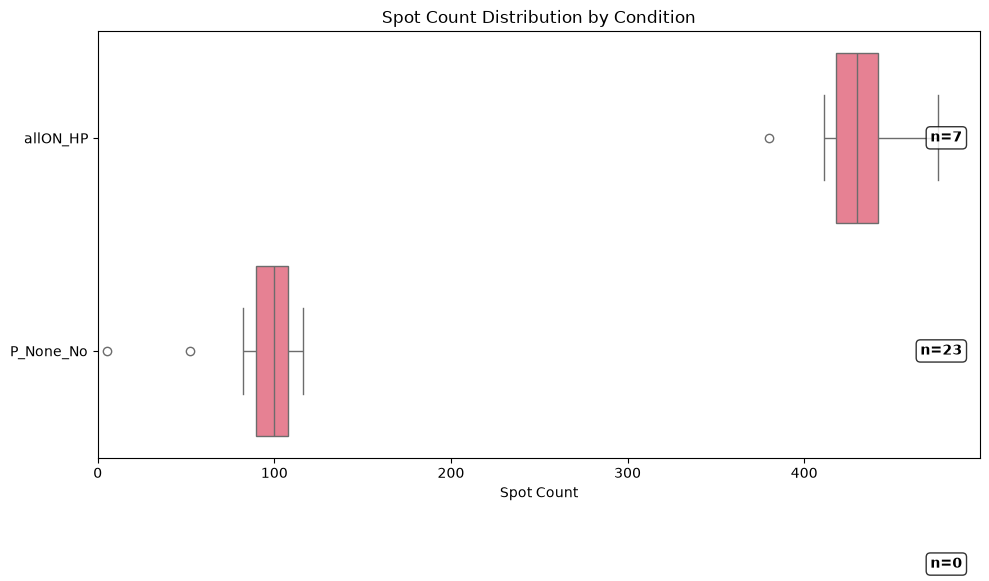

In [3]:
# Set up the plotting style
plt.style.use("default")
sns.set_palette("husl")

# Figure: Spot count distribution by condition
fig, ax = plt.subplots(figsize=(10, 6))


def add_n_annotations(ax, data_col, group_col="Condition"):
    """Add sample size annotations to boxplot"""
    conditions = df[group_col].unique()
    for i, condition in enumerate(conditions):
        n = len(df[df[group_col] == condition])
        ax.text(
            ax.get_xlim()[1] * 0.98,
            i,
            f"n={n}",
            verticalalignment="center",
            horizontalalignment="right",
            fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8),
        )


sns.boxplot(data=df, y="Condition", x="Spot_Count", ax=ax)
ax.set_title("Spot Count Distribution by Condition")
ax.set_ylabel("")
ax.set_xlabel("Spot Count")
add_n_annotations(ax, "Spot_Count")
ax.set_xlim(left=0)

plt.tight_layout()
plt.show()